In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

#Load NAV Data


In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


#Calculate Daily Returns


In [5]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


#Validate Daily Returns


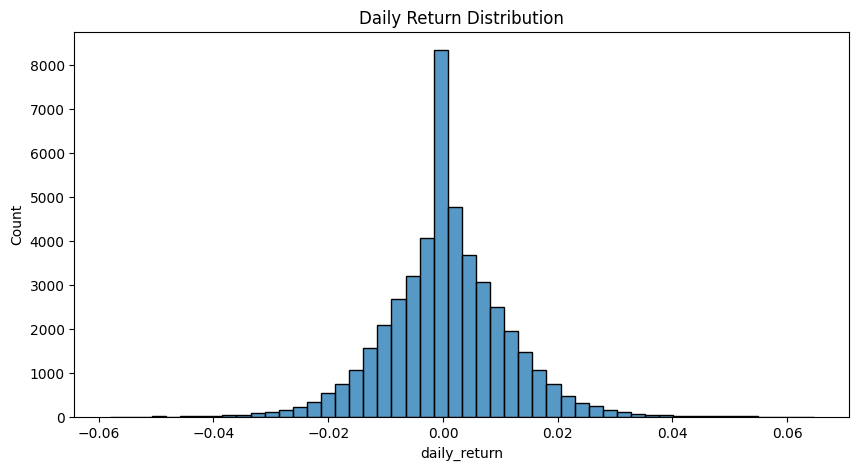

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

#Calculate CAGR


In [7]:
cagr_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code']==fund]

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max()
        -
        temp['date'].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)**(1/years)
        -
        1
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code','cagr']
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


#Sharp Ratio


In [8]:
rf = 0.065

sharpe_list = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    mean_return = temp['daily_return'].mean()

    std_return = temp['daily_return'].std()

    sharpe = (
        (mean_return-rf/252)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['amfi_code','sharpe']
)

#Sortino Ratio


In [9]:
sortino_list = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    downside = temp[
        temp['daily_return'] < 0
    ]['daily_return']

    sortino = (
        (temp['daily_return'].mean()-0.065/252)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=['amfi_code','sortino']
)

In [26]:
benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark=benchmark.sort_values('date')
benchmark['benchmark_return'] =( benchmark['close_value'].pct_change())
benchmark.head()


,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [27]:
nav['date'] = pd.to_datetime(nav['date'])
nav=nav.sort_values(['amfi_code', 'date'])
nav['daily_return']=(nav.groupby('amfi_code')['nav'].pct_change())

#Alpha & Beta


In [29]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

In [35]:
benchmark['date'] = pd.to_datetime(benchmark['date'])
print(nav['date'].dtype)
print(benchmark['date'].dtype)

datetime64[us]
datetime64[us]


In [36]:
print(nav.columns)
print(benchmark.columns)
print(nav['date'].dtype)
print(benchmark['date'].dtype)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
datetime64[us]
datetime64[us]


In [37]:
benchmark=benchmark.sort_values('date')
benchmark['close_value']=pd.to_numeric(benchmark['close_value'])
benchmark['benchmark_return'] =( benchmark['close_value'].pct_change())
benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [38]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [39]:
merged = pd.merge(
    temp,
    benchmark[['date','benchmark_return']],
              on='date',    
              how='inner'
)
print(merged.head())

   amfi_code       date       nav  daily_return  benchmark_return
0     100016 2022-01-03  520.4608           NaN               NaN
1     100016 2022-01-03  520.4608           NaN         -0.869574
2     100016 2022-01-03  520.4608           NaN          3.261121
3     100016 2022-01-03  520.4608           NaN         -0.850741
4     100016 2022-01-03  520.4608           NaN         11.251899


In [42]:
from scipy.stats import linregress
alpha_beta = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    merged = pd.merge(
        temp,
        benchmark[['date','benchmark_return']],
        on='date',
        how='inner'
    )
    
    merged=merged.dropna()
    if  len(merged) < 10:
        continue

    slope, intercept, r, p, std = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)
alpha_beta_df.head()

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


#Maximum Drawdown


In [43]:
mdd_list = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ].copy()

    temp['running_max'] = (
        temp['nav'].cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        -
        1
    )

    max_dd = temp['drawdown'].min()

    mdd_list.append(
        [fund,max_dd]
    )

mdd_df = pd.DataFrame(
    mdd_list,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

#Fund Scorecard


In [44]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(sortino_df)
    .merge(mdd_df)
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)


#Benchmark Comparison Chart


In [45]:
top5 = scorecard.nlargest(
    5,
    'cagr'
)


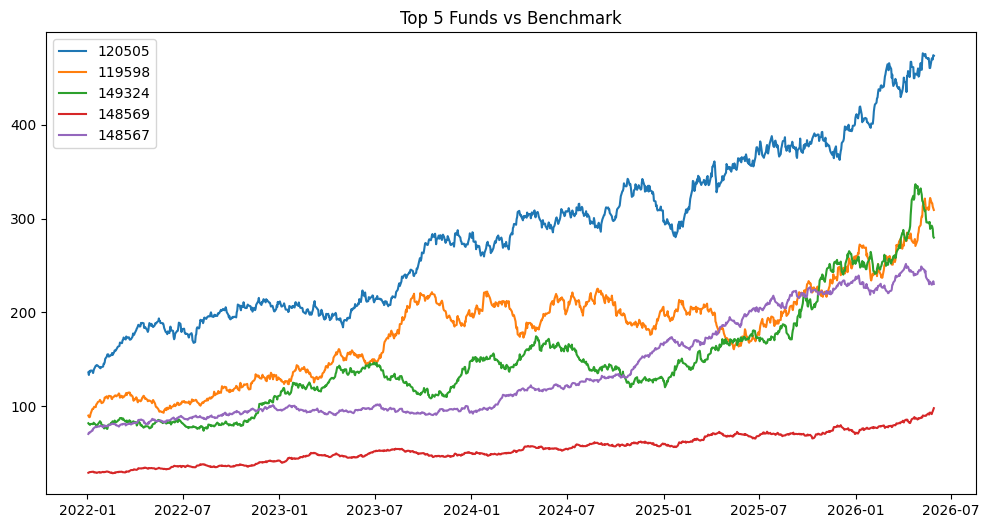

In [46]:
plt.figure(figsize=(12,6))

for fund in top5['amfi_code']:

    temp = nav[
        nav['amfi_code']==fund
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=fund
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()